<a href="https://colab.research.google.com/github/Balachandar-Ganesan/DeepLearning/blob/main/009_100_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step #100 Loss: 0.4546
Step #200 Loss: 0.3268
Step #300 Loss: 0.2195
Step #400 Loss: 0.1504
Step #500 Loss: 0.1520


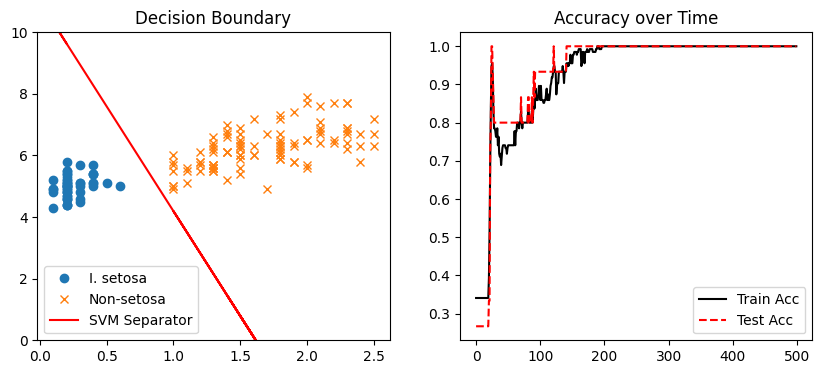

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn import datasets

# 1. Reproducibility
np.random.seed(7)
tf.random.set_seed(7)

# 2. Load and Prepare Data
iris = datasets.load_iris()
# x1 = Sepal Length (index 0), x2 = Petal Width (index 3)
x_vals = np.array([[x[0], x[3]] for x in iris.data], dtype=np.float32)
y_vals = np.array([1 if y == 0 else -1 for y in iris.target], dtype=np.float32).reshape(-1, 1)

# Split data
train_indices = np.random.choice(len(x_vals), int(round(len(x_vals)*0.9)), replace=False)
test_indices = np.array(list(set(range(len(x_vals))) - set(train_indices)))

x_train, x_test = x_vals[train_indices], x_vals[test_indices]
y_train, y_test = y_vals[train_indices], y_vals[test_indices]

# 3. Model Variables
batch_size = 135
learning_rate = 0.01
iterations = 500
alpha = 0.01  # L2 regularization parameter

A = tf.Variable(tf.random.normal(shape=(2, 1)))
b = tf.Variable(tf.random.normal(shape=(1, 1)))
optimizer = tf.keras.optimizers.SGD(learning_rate)

# 4. Training Loop
loss_vec, train_accuracy, test_accuracy = [], [], []

for i in range(iterations):
    rand_index = np.random.choice(len(x_train), size=batch_size)
    rand_x, rand_y = x_train[rand_index], y_train[rand_index]

    with tf.GradientTape() as tape:
        # Model: Output = (x * A) - b
        model_output = tf.subtract(tf.matmul(rand_x, A), b)

        # Hinge Loss (Soft Margin): max(0, 1 - pred*actual)
        classification_term = tf.reduce_mean(tf.maximum(0., 1. - model_output * rand_y))
        l2_norm = tf.reduce_sum(tf.square(A))
        loss = classification_term + (alpha * l2_norm)

    # Apply Gradients
    gradients = tape.gradient(loss, [A, b])
    optimizer.apply_gradients(zip(gradients, [A, b]))

    # Track Metrics
    loss_vec.append(loss.numpy())

    # Calculate Accuracies
    train_acc = tf.reduce_mean(tf.cast(tf.equal(tf.sign(tf.matmul(x_train, A) - b), y_train), tf.float32))
    test_acc = tf.reduce_mean(tf.cast(tf.equal(tf.sign(tf.matmul(x_test, A) - b), y_test), tf.float32))
    train_accuracy.append(train_acc.numpy())
    test_accuracy.append(test_acc.numpy())

    if (i + 1) % 100 == 0:
        print(f"Step #{i+1} Loss: {loss.numpy():.4f}")

# 5. Extract Coefficients for Plotting
[[a1], [a2]] = A.numpy()
[[b_val]] = b.numpy()
# Decision boundary: x1*a1 + x2*a2 - b = 0 => x1 = (-a2/a1)x2 + (b/a1)
slope = -a2/a1
y_intercept = b_val/a1

# 6. Visualization
x2_vals = x_vals[:, 1]
best_fit = slope * x2_vals + y_intercept

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(x_vals[y_vals.flatten()==1, 1], x_vals[y_vals.flatten()==1, 0], 'o', label='I. setosa')
plt.plot(x_vals[y_vals.flatten()==-1, 1], x_vals[y_vals.flatten()==-1, 0], 'x', label='Non-setosa')
plt.plot(x2_vals, best_fit, 'r-', label='SVM Separator')
plt.ylim([0, 10]); plt.legend(); plt.title('Decision Boundary')

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'k-', label='Train Acc')
plt.plot(test_accuracy, 'r--', label='Test Acc')
plt.legend(); plt.title('Accuracy over Time')
plt.show()
